# 미니프로젝트: 차원 축소와 SHAP Value (Vibe Coding)

#### <목표>
오늘 배운 **mRMR, Boruta, SHAP Value**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 인코딩된 고객 정보로 이탈 여부 예측 및 변수 해석 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day5_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)
- 지난 미니프로젝트에서 다룬 전처리를 모두 적용한 뒤 시작하세요.

**[과제]** 써니는 어제 실습에서 사용한 통신사 고객 이탈(Churn) 데이터를 활용하여 분석을 진행하고자 합니다. 필요한 라이브러리와 데이터를 불러오세요.

In [4]:
# 기본
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 전처리/분할/평가
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

# 모델 (mRMR/Boruta/SHAP에서 같이 쓰기 좋음)
from sklearn.ensemble import RandomForestClassifier

# mRMR
from mrmr import mrmr_classif

# Boruta
from boruta import BorutaPy

# SHAP
import shap

churn_data = pd.read_csv("dataset/day5_miniproject.csv")
churn_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**[과제]** 써니는 어제 진행한 통신사 고객 이탈 데이터 전처리 과정을 재사용하고자 합니다. Agent 기능을 활용하여 '머신러닝 Day4. 미니프로젝트.ipynb' 파일에서 전처리 코드를 찾아 실행하고 동일한 데이터 전처리 결과를 재현해 보세요.

> 입력변수, 출력변수 분할 / 학습 데이터, 테스트 데이터 분할 / 결측치 처리 / 스케일링, 인코딩

[프롬프트]
'churn_data'는 어제 '머신러닝 Day4. 미니프로젝트.ipynb'에서 다뤘던 데이터야. 전처리를 다시 수행할거야.
1. 출력변수 Churn은 No:0, Yes:1로 인코딩 필요. 우리는 이탈 고객에 관심이 있으니까.
2. 입력/출력 변수를 분할하고, 학습/테스트 데이터도 분할 진행.
3. 결측치 처리는 어제와 동일하게: 명목형은 'missing'처리하고 수치형 tenure, MonthlyCharges 결측치는 KNN(k=5)으로 채우기. 둘다 결측인 행은 삭제.
4. 수치형 변수들은 standard scaling 진행하고, 명목형 변수들 중 이항 분포 변수는 ordinary, 3개 이상 분포하는 경우 원-핫 인코딩 진행.

In [5]:

# 0) 타겟 인코딩 (No:0, Yes:1) - 우리는 이탈(Yes=1)에 관심
churn = churn_data.copy()
churn["Churn"] = churn["Churn"].map({"No": 0, "Yes": 1}).astype(int)

# 1) 입력/출력 분리
X = churn.drop(columns=["Churn"])
y = churn["Churn"]

# 2) 결측치 처리
# 2-1) 명목형 결측치는 'missing'으로 채움
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
X[cat_cols] = X[cat_cols].fillna("missing")

# 2-2) 수치형 결측: tenure, MonthlyCharges만 KNN(k=5)
num_knn_cols = ["tenure", "MonthlyCharges"]

# 둘 다 결측인 행은 삭제
both_missing = X[num_knn_cols].isna().all(axis=1)
print(f"tenure & MonthlyCharges 둘 다 결측인 행 삭제: {both_missing.sum()}개")
X = X.loc[~both_missing].copy()
y = y.loc[X.index].copy()

from sklearn.impute import KNNImputer
knn_imp = KNNImputer(n_neighbors=5)
X[num_knn_cols] = knn_imp.fit_transform(X[num_knn_cols])

# 3) 학습/테스트 분할 (분류이므로 stratify 권장)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4) 인코딩/스케일링
# - 수치형: Standard Scaling
# - 명목형:
#   - 이항(2개 값) 변수: OrdinalEncoder
#   - 3개 이상: OneHotEncoder

# 이항 변수는 '원본에서 결측 제외' 고유값이 2개 이하인 컬럼
binary_cols = []
multicat_cols = []
for c in cat_cols:
    n_unique = churn_data[c].dropna().nunique()
    if n_unique <= 2:
        binary_cols.append(c)
    else:
        multicat_cols.append(c)

num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("bin", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), binary_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), multicat_cols),
    ],
    remainder="drop",
)

# 전처리된 행렬 생성(추후 mRMR/Boruta/SHAP용)
X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

# 전처리 후 컬럼명 복원 (OneHot 포함)
feature_names = preprocess.get_feature_names_out()
X_train_prep = pd.DataFrame(X_train_prep, columns=feature_names, index=X_train.index)
X_test_prep = pd.DataFrame(X_test_prep, columns=feature_names, index=X_test.index)

print("전처리 완료")
print("X_train:", X_train.shape, "->", X_train_prep.shape)
print("X_test :", X_test.shape, "->", X_test_prep.shape)
print("y_train 분포:")
print(y_train.value_counts(normalize=True).round(3))


tenure & MonthlyCharges 둘 다 결측인 행 삭제: 3개
전처리 완료
X_train: (4928, 19) -> (4928, 42)
X_test : (2112, 19) -> (2112, 42)
y_train 분포:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


## 1) 다중공선성 확인

**[과제]** 써니는 인코딩된 변수들의 상관행렬을 히트맵으로 그려보고 어떤 변수끼리 상관관계가 높은지 AI와 함께 확인해 보세요.

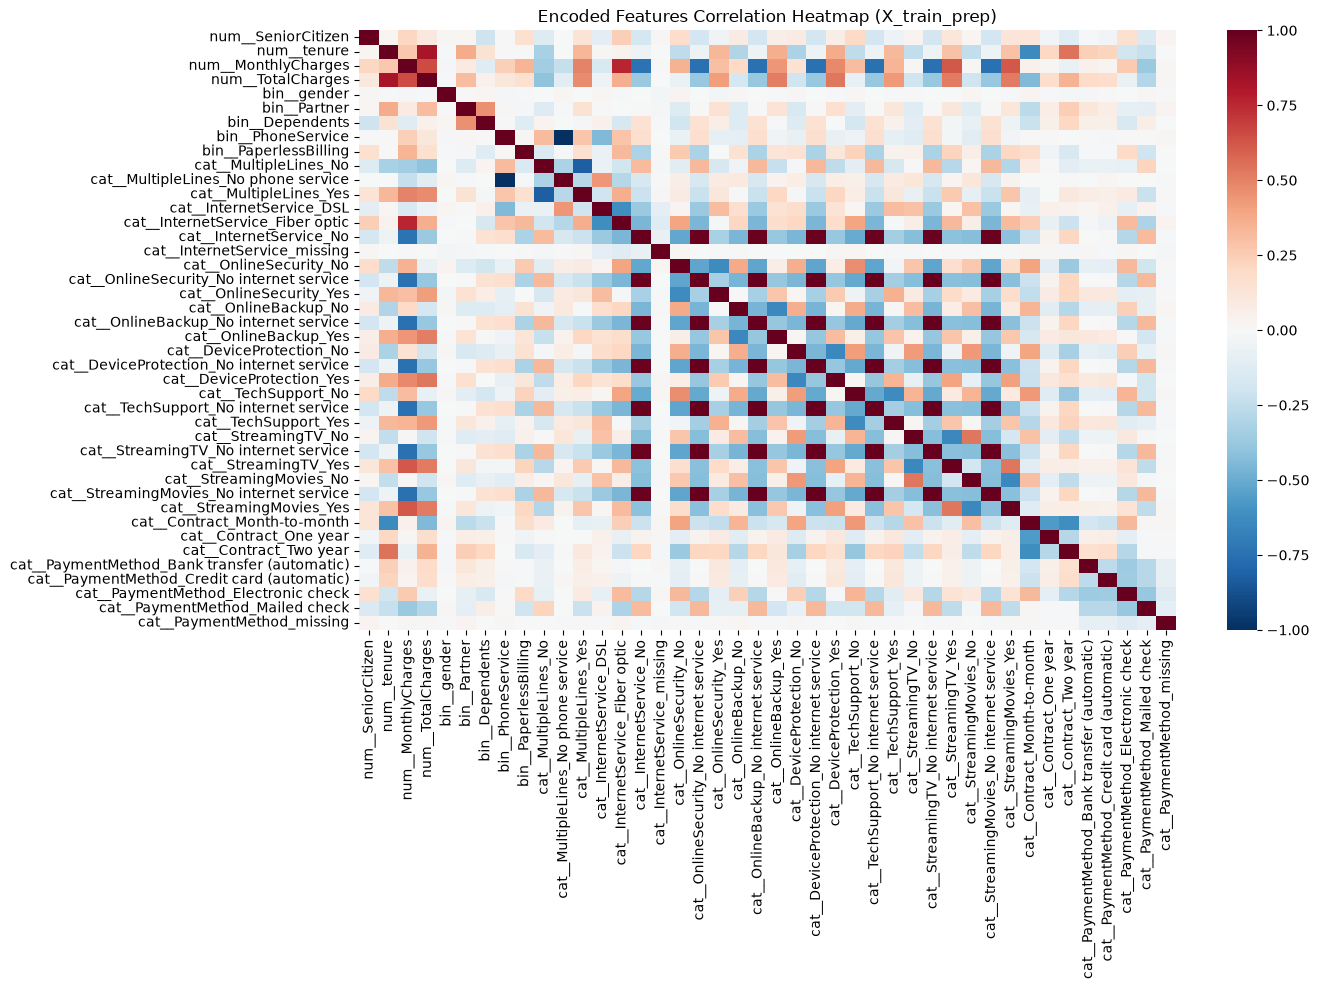

절대 상관계수 상위 20쌍


cat__OnlineBackup_No internet service      cat__OnlineSecurity_No internet service      1.0
                                           cat__StreamingTV_No internet service         1.0
                                           cat__DeviceProtection_No internet service    1.0
                                           cat__StreamingMovies_No internet service     1.0
                                           cat__TechSupport_No internet service         1.0
cat__OnlineSecurity_No internet service    cat__TechSupport_No internet service         1.0
cat__TechSupport_No internet service       cat__DeviceProtection_No internet service    1.0
cat__DeviceProtection_No internet service  cat__StreamingMovies_No internet service     1.0
                                           cat__StreamingTV_No internet service         1.0
                                           cat__TechSupport_No internet service         1.0
cat__MultipleLines_No phone service        bin__PhoneService                    

In [6]:

# 인코딩/스케일링까지 끝난 X_train_prep(DataFrame) 기준 상관행렬 히트맵
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_train_prep.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Encoded Features Correlation Heatmap (X_train_prep)")
plt.tight_layout()
plt.show()

# 상관관계가 높은 변수 쌍(top N) 뽑기 (절대값 기준) - 수정 버전
abs_corr = corr.abs().copy()

# 대각선(자기 자신과의 상관) 제거
abs_corr = abs_corr.where(~np.eye(abs_corr.shape[0], dtype=bool))

top_n = 20
pairs = (
    abs_corr.unstack()
    .dropna()
    .sort_values(ascending=False)
)

# (A,B)와 (B,A) 중복 제거
pairs = pairs[~pairs.index.map(lambda x: (x[1], x[0])).duplicated()].head(top_n)

print(f"절대 상관계수 상위 {top_n}쌍")
display(pairs)

**[과제]** 써니는 변수 선택법과 SHAP 분석을 적용하기 전에 전체 변수를 사용한 Random Forest 분류 모델의 성능을 기준으로 삼고자 합니다. AI와 상의하여 모델을 학습하고, Accuracy, Precision, Recall, F1-score를 계산하여 성능을 확인하는 코드를 작성해 보세요.

In [6]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# 전체 변수(전처리된 X_train_prep, X_test_prep)로 Random Forest 학습
rf_all = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_all.fit(X_train_prep, y_train)

# 예측
y_pred = rf_all.predict(X_test_prep)

# 성능 평가
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)   # 이탈(1) 기준
rec = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("[전체 변수 사용 - Random Forest Baseline]")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=["No(0)", "Yes(1)"]))

print("[Confusion Matrix]")
display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"]))


[전체 변수 사용 - Random Forest Baseline]
Accuracy : 0.7751
Precision: 0.5649
Recall   : 0.6607
F1-score : 0.6091

[Classification Report]
              precision    recall  f1-score   support

       No(0)       0.87      0.82      0.84      1552
      Yes(1)       0.56      0.66      0.61       560

    accuracy                           0.78      2112
   macro avg       0.72      0.74      0.73      2112
weighted avg       0.79      0.78      0.78      2112

[Confusion Matrix]


,Pred 0,Pred 1
True 0,1267,285
True 1,190,370


[AI의 결과 해석]
현재 baseline(Random Forest, 전체 변수) 결과는 **“전체 정확도는 괜찮지만, 우리가 관심 있는 이탈(1) 고객을 잡는 성능은 중간 수준”** 으로 해석하면 됩니다.

### 핵심 지표(이탈=1 기준)
- **Accuracy = 0.775**: 전체(유지+이탈)를 합쳐서 **77.5%** 맞춤  
  - 다만 데이터가 **유지(0)가 더 많아서**(True0=1552, True1=560) 정확도만 보면 과대평가될 수 있어요.
- **Precision(이탈) = 0.565**: 모델이 “이탈”이라고 예측한 사람 중 **56.5%만 실제 이탈**  
  - 즉, **이탈 예측의 절반 정도는 오경보(FP)** 라는 뜻.
- **Recall(이탈) = 0.661**: 실제 이탈 고객 중 **66.1%를 잡음**  
  - 우리가 “이탈을 놓치면 손해”라면 중요한 지표이고, 현재는 **3명 중 1명은 놓침**.
- **F1(이탈) = 0.609**: Precision/Recall 균형 종합점수 → **중간 정도**

### Confusion Matrix로 구체적으로 보면
- **TP(이탈을 이탈로 맞춤)** = 370  
- **FN(이탈인데 유지로 놓침)** = 190  → 실제 이탈 560명 중 **190명을 놓침(33.9%)**
- **FP(유지인데 이탈로 오경보)** = 285 → 유지 1552명 중 **285명을 잘못 이탈로 판단(18.4%)**
- **TN(유지를 유지로 맞춤)** = 1267

정리하면:
- **이탈을 꽤 잡긴 하지만(FN 190)**, 여전히 놓치는 고객이 많고
- **이탈 예측을 하면 오경보(FP 285)**도 제법 발생합니다.

### 지금 결과의 의미(다음 단계와 연결)
- 이 성능이 **기준선(baseline)** 이고,
- 이후 **mRMR/Boruta로 변수 선택**을 하면  
  - 성능이 유지되거나 좋아지는지, 특히 **Recall(이탈)과 F1**이 개선되는지 확인하면 됩니다.
- 그리고 SHAP은 “왜 이탈로 예측했는지”를 **개별 고객/변수 영향**으로 설명하는 단계입니다.

원하시면, 비즈니스 관점(이탈 놓침 vs 오경보 중 뭐가 더 비용이 큰지)에 맞춰 **threshold 조정(확률 기준)** 으로 Recall을 더 올리는 방법도 같이 안내해드릴게요.

## 2) mRMR 변수 선택

**[과제]** 써니는 mRMR을 활용해 중요한 변수를 선택해보고자 합니다. AI와 상의해서 가장 적합한 k를 결정하고 선택된 변수로 모델을 다시 학습시켜 전체 변수를 사용했을 때 때와 성능을 비교해 보세요.

[프롬프트]
mRMR을 활용해 중요한 변수를 선택해봅시다. 
1.적합한 k는 어떻게 결정하면 될까요? 
2.중요하다고 선택된 변수로 모델을 다시 학습시키면 전체 변수를 사용 했을 때와 성능이 어떻게 차이가 날까요?

[AI의 대답]
### 1) mRMR의 적합한 \(k\)는 어떻게 결정해?
정답은 **“검증 성능이 가장 좋은 \(k\)”**로 고르는 겁니다. 보통은

- **후보 \(k\)**(예: 5~40)를 여러 개 두고
- 각 \(k\)마다 mRMR로 변수 선택 → 그 변수들로 모델 학습
- **Stratified K-Fold CV**에서 우리가 관심 있는 지표(보통 **F1(이탈=1)** 또는 **Recall(이탈=1)**, 혹은 ROC-AUC)를 비교
- **가장 성능이 좋은 \(k\)**를 선택합니다.

---

### 2) 선택된 변수로 다시 학습하면 성능이 어떻게 달라져?
데이터/모델에 따라 달라집니다.

- **좋아질 수 있음**: 중복/노이즈 변수를 줄여서 일반화가 좋아질 때
- **비슷할 수 있음**: 이미 RF가 쓸 변수만 알아서 쓰는 경우
- **나빠질 수 있음**: 비선형 상호작용에 필요한 변수를 mRMR(상관 기반)이 빼버릴 때

아래 코드를 돌리면 **baseline(전체 변수)** vs **mRMR(k*)**를 바로 비교할 수 있어요.
원하면 CV 기준을 **F1 대신 Recall(이탈=1)**로 바꿔서 “이탈을 더 놓치지 않는 \(k\)”를 고르는 버전도 같이 만들어드릴게요.

In [8]:

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from mrmr import mrmr_classif

# ----------------------------
# 0) baseline (전체 변수) 성능
# ----------------------------
def eval_on_test(model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {
        "acc": accuracy_score(yte, pred),
        "prec(1)": precision_score(yte, pred, pos_label=1),
        "recall(1)": recall_score(yte, pred, pos_label=1),
        "f1(1)": f1_score(yte, pred, pos_label=1),
    }

rf_params = dict(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

baseline = eval_on_test(
    RandomForestClassifier(**rf_params),
    X_train_prep, y_train,
    X_test_prep, y_test
)
print("[Baseline: 전체 변수]")
print(baseline)

# -----------------------------------------
# 1) k 후보를 두고 CV로 best_k 찾기 (F1 기준)
# -----------------------------------------
k_list = [5, 8, 10, 12, 15, 20, 25, 30, 35, 40]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_results = []
for k in k_list:
    # mRMR는 DataFrame 입력을 기대 → X_train_prep는 DataFrame이어야 함
    selected = mrmr_classif(X_train_prep, y_train, K=k)

    f1s = []
    for tr_idx, va_idx in skf.split(X_train_prep, y_train):
        X_tr = X_train_prep.iloc[tr_idx][selected]
        y_tr = y_train.iloc[tr_idx]
        X_va = X_train_prep.iloc[va_idx][selected]
        y_va = y_train.iloc[va_idx]

        m = RandomForestClassifier(**rf_params)
        m.fit(X_tr, y_tr)
        pred = m.predict(X_va)
        f1s.append(f1_score(y_va, pred, pos_label=1))

    k_results.append({"k": k, "cv_f1(1)_mean": float(np.mean(f1s)), "cv_f1(1)_std": float(np.std(f1s))})
    print(f"k={k:>2} | CV F1(1)={np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

k_df = pd.DataFrame(k_results).sort_values("cv_f1(1)_mean", ascending=False)
best_k = int(k_df.iloc[0]["k"])
print("\n[Best k]")
display(k_df)
print("best_k =", best_k)

# -----------------------------------------
# 2) best_k로 변수 선택 후, 테스트 성능 비교
# -----------------------------------------
selected_mrmr = mrmr_classif(X_train_prep, y_train, K=best_k)
print(f"mRMR 선택 변수 수: {len(selected_mrmr)}")
print(selected_mrmr)

mrmr_perf = eval_on_test(
    RandomForestClassifier(**rf_params),
    X_train_prep[selected_mrmr], y_train,
    X_test_prep[selected_mrmr], y_test
)
print("\n[mRMR 선택 변수 사용]")
print(mrmr_perf)

# ----------------------------
# 3) baseline vs mRMR 비교표
# ----------------------------
compare = pd.DataFrame([baseline, mrmr_perf], index=["Baseline(all)", f"mRMR(k={best_k})"])
display(compare)

[Baseline: 전체 변수]
{'acc': 0.775094696969697, 'prec(1)': 0.5648854961832062, 'recall(1)': 0.6607142857142857, 'f1(1)': 0.6090534979423868}


100%|██████████| 5/5 [00:00<00:00, 31.35it/s]


k= 5 | CV F1(1)=0.5456 ± 0.0204


100%|██████████| 8/8 [00:00<00:00, 39.64it/s]


k= 8 | CV F1(1)=0.5574 ± 0.0163


...

,k,cv_f1(1)_mean,cv_f1(1)_std
8,35,0.617441,0.015872
7,30,0.606456,0.019321
9,40,0.600441,0.014693
5,20,0.593766,0.020070
6,25,0.590122,0.022673
4,15,0.590119,0.028285
3,12,0.589587,0.006277
2,10,0.581664,0.008233
1,8,0.557436,0.016312
0,5,0.545552,0.020425


best_k = 35


100%|██████████| 35/35 [00:01<00:00, 33.02it/s]


mRMR 선택 변수 수: 35
['cat__Contract_Month-to-month', 'num__MonthlyCharges', 'cat__TechSupport_No', 'cat__PaymentMethod_Electronic check', 'num__tenure', 'cat__OnlineSecurity_No', 'cat__InternetService_Fiber optic', 'cat__Contract_Two year', 'cat__OnlineBackup_No', 'cat__DeviceProtection_No', 'bin__PaperlessBilling', 'cat__Contract_One year', 'bin__Dependents', 'cat__OnlineSecurity_Yes', 'cat__InternetService_No', 'cat__PaymentMethod_Credit card (automatic)', 'cat__OnlineSecurity_No internet service', 'bin__Partner', 'num__SeniorCitizen', 'cat__OnlineBackup_No internet service', 'cat__PaymentMethod_Bank transfer (automatic)', 'cat__TechSupport_Yes', 'cat__DeviceProtection_No internet service', 'cat__TechSupport_No internet service', 'cat__StreamingTV_No internet service', 'cat__StreamingMovies_No internet service', 'num__TotalCharges', 'cat__StreamingMovies_No', 'cat__StreamingTV_No', 'cat__InternetService_DSL', 'cat__PaymentMethod_Mailed check', 'cat__OnlineBackup_Yes', 'cat__StreamingTV_

,acc,prec(1),recall(1),f1(1)
Baseline(all),0.775095,0.564885,0.660714,0.609053
mRMR(k=35),0.770360,0.558685,0.637500,0.595496


[왜 mRMR으로 선택한 변수로 재학습한 모델이 성능이 더 안좋은걸까?]

mRMR로 고른 변수로 성능이 조금 떨어진 건 자연스러운 경우가 많아요. 지금 결과도 **“큰 폭 하락”이 아니라, 정보가 조금 빠지면서 Recall/F1이 소폭 내려간** 패턴입니다(Recall 0.661→0.638, F1 0.609→0.595).

### 왜 이런 일이 생길까? (핵심 원인 4가지)

#### 1) mRMR의 기준이 RF의 기준과 다름
- **mRMR**: 각 변수와 타깃의 **(주로 선형) 관련성** + 변수끼리 중복 최소화
- **Random Forest**: **비선형/상호작용**을 이용해 성능을 올림

즉, RF는 “둘이 같이 있을 때 의미가 커지는 변수 조합(상호작용)”을 쓰기도 하는데, mRMR은 그런 변수를 **단독으로 덜 관련 있어 보이면** 빼버릴 수 있어요. 그러면 성능이 떨어집니다.

#### 2) Churn 데이터는 범주형이 많고(원-핫), “조합”이 중요함
원-핫 변수는 한 변수만 보면 힘이 약해도,
- 예: `Contract=Month-to-month` 와 `PaymentMethod=Electronic check`가 같이 있을 때 churn이 확 올라가는 식
으로 **조합 효과**가 큽니다.  
mRMR은 이런 조합 효과를 충분히 반영하지 못할 수 있습니다.

#### 3) k를 “CV F1”로 골랐어도, 테스트에서는 조금 흔들릴 수 있음
CV는 훈련 데이터 안에서의 평균 성능이고,
테스트는 한 번의 분할 결과라서 **약간의 성능 차이는 샘플링 변동**으로도 생깁니다.  
(지금 차이 정도는 충분히 그 범위 안입니다.)

#### 4) RF는 원래 “불필요한 변수”에 비교적 강함
Random Forest는 많은 변수가 있어도
- split에서 유용한 변수만 알아서 고르고
- 덜 유용한 변수는 거의 안 쓰는
특성이 있습니다.  
그래서 **변수 선택으로 얻는 이득이 생각보다 작고**, 오히려 “조금이라도 중요한 변수”를 빼면 성능이 내려갈 수 있어요.

---

## 선생님식 결론
> **mRMR은 “선형적으로 잘 설명되는 핵심 변수”를 뽑는 데 강하지만,  
> Random Forest는 “비선형·상호작용 정보”로 성능을 내기 때문에,  
> mRMR로 변수를 줄이면 그 상호작용 정보가 일부 사라져 성능이 떨어질 수 있다.**

---

## 실무적으로는 이렇게 해보면 좋아요
- **목표가 성능**이면: mRMR 결과를 “최종”으로 쓰기보다  
  - Boruta(모델 기반 all-relevant)나
  - RF 자체 중요도/Permutation importance,
  - 또는 규제 모델(L1 logistic)과 비교
  를 같이 봅니다.
- **목표가 해석/간결함**이면: 성능이 조금 떨어져도 mRMR을 채택할 가치가 있습니다(설명 가능한 변수 집합).

원하시면, 지금 mRMR로 선택된 35개 변수 중에서 **RF 중요도 상위와 겹치는지(겹침 비율)**를 확인해서 “어떤 정보가 빠졌는지”까지 같이 분석해드릴게요.

## 3) Boruta 변수 선택

**[과제]** 써니는 Boruta로도 변수를 선택해보고자 합니다. AI와 상의하여 관련 코드를 작성하세요.

In [10]:
# BorutaPy는 NaN이 한 개라도 있으면 바로 실패합니다. 지금 X_train_prep 안에 NaN이 남아있는 게 원인이에요.
# (대부분 TotalCharges가 문자열/공백 처리 때문에 NaN이 생기거나, 인코딩 과정에서 누락된 경우가 흔합니다.)
# 아래 코드로 NaN 원인 확인 → 처리 → Boruta 실행 순서로 진행하세요.


# 0) NaN 확인 (전처리된 데이터 기준)
print("X_train_prep NaN 개수:", X_train_prep.isna().sum().sum())
nan_cols = X_train_prep.columns[X_train_prep.isna().any()].tolist()
print("NaN 포함 컬럼 수:", len(nan_cols))
print("NaN 포함 컬럼(상위 20개):", nan_cols[:20])

# 1) NaN 처리 (가장 안전: 수치형 전체를 median으로 채움)
# - 원핫/ordinal 결과는 대부분 0/1 or 정수라 NaN이 거의 없고,
#   남는 NaN은 보통 수치형에서 발생하므로 median 대치가 무난합니다.
X_train_boruta = X_train_prep.copy()
X_test_boruta = X_test_prep.copy()

X_train_boruta = X_train_boruta.fillna(X_train_boruta.median(numeric_only=True))
X_test_boruta = X_test_boruta.fillna(X_train_boruta.median(numeric_only=True))  # train 기준으로 채우기

print("NaN after fill (train):", X_train_boruta.isna().sum().sum())
print("NaN after fill (test) :", X_test_boruta.isna().sum().sum())

# 2) Boruta 실행
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

rf_for_boruta = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
    max_depth=10
)

boruta = BorutaPy(
    estimator=rf_for_boruta,
    n_estimators="auto",
    max_iter=50,
    perc=100,
    random_state=42
)

boruta.fit(X_train_boruta.values, y_train.values)

confirmed_cols = X_train_boruta.columns[boruta.support_].tolist()
tentative_cols = X_train_boruta.columns[boruta.support_weak_].tolist()

print(f"총 변수 수: {X_train_boruta.shape[1]}")
print(f"확정(confirmed): {len(confirmed_cols)}")
print(f"미정(tentative): {len(tentative_cols)}")

# 3) 확정 변수로 재학습/평가
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_boruta = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_boruta.fit(X_train_boruta[confirmed_cols], y_train)
pred = rf_boruta.predict(X_test_boruta[confirmed_cols])

print("\n[Boruta confirmed - Test 성능]")
print({
    "acc": accuracy_score(y_test, pred),
    "prec(1)": precision_score(y_test, pred, pos_label=1),
    "recall(1)": recall_score(y_test, pred, pos_label=1),
    "f1(1)": f1_score(y_test, pred, pos_label=1),
})

X_train_prep NaN 개수: 7
NaN 포함 컬럼 수: 1
NaN 포함 컬럼(상위 20개): ['num__TotalCharges']
NaN after fill (train): 0
NaN after fill (test) : 0
총 변수 수: 42
확정(confirmed): 6
미정(tentative): 1

[Boruta confirmed - Test 성능]
{'acc': 0.7400568181818182, 'prec(1)': 0.508100147275405, 'recall(1)': 0.6160714285714286, 'f1(1)': 0.5569007263922519}


**한 줄 결론**
>Boruta의 confirmed는 “확실한 변수”라서 너무 적게 남는 경우가 많고, churn처럼 조합이 중요한 문제에서는 confirmed만 쓰면 정보가 부족해져 성능이 떨어질 수 있다. 그래서 tentative까지 포함해서 비교하는 것이 실무적으로 더 타당하다.

## 4) 성능 비교 요약

**[과제]** 써니는 전체 변수/mRMR/Boruta 세 가지 방법의 성능을 표로 정리하고 변수 수를 줄였을 때 성능이 어떻게 변하는지 AI와 함께 해석해 보세요.

### 1) 성능 표 정리 (현재 결과 기준)

| 방법 | 변수 수 | Accuracy | Precision(이탈=1) | Recall(이탈=1) | F1(이탈=1) |
|---|---:|---:|---:|---:|---:|
| **전체 변수(Baseline)** | 42 | **0.7751** | **0.5649** | **0.6607** | **0.6091** |
| **mRMR (k=35)** | 35 | 0.7704 | 0.5587 | 0.6375 | 0.5955 |
| **Boruta (confirmed)** | 6 | 0.7401 | 0.5081 | 0.6161 | 0.5569 |

---

### 2) 변수 수를 줄였을 때 성능이 어떻게 변했나?

#### **(1) 42 → 35개 (mRMR)**
- 성능이 **거의 비슷하지만 소폭 하락**
  - Recall: 0.6607 → 0.6375  
  - F1: 0.6091 → 0.5955
- 해석: mRMR이 일부 유용한 정보를 줄이긴 했지만, **큰 손실은 없을 정도로 핵심 정보는 유지**된 상태입니다.  
  즉, “변수 7개 줄인 대가로 성능이 약간 떨어진” 정도예요.

#### **(2) 42 → 6개 (Boruta confirmed)**
- 성능이 **눈에 띄게 하락**
  - Accuracy: 0.7751 → 0.7401  
  - Precision: 0.5649 → 0.5081  
  - Recall: 0.6607 → 0.6161  
  - F1: 0.6091 → 0.5569
- 해석: 변수 6개만으로는 churn(이탈) 예측에 필요한 정보가 부족해져서,
  - 이탈을 더 많이 놓치고(Recall↓)
  - 이탈이라고 찍은 것의 신뢰도도 떨어지며(Precision↓)
  - 종합 성능(F1)도 같이 내려간 것입니다.

---

### 3) 선생님식 결론

- **Random Forest는 원래 많은 변수가 있어도 “쓸 변수만 알아서 쓰는” 모델**이라서,  
  변수를 조금 줄이는 것(mRMR 35개)은 성능이 크게 망가지지 않습니다.
- 반면 Boruta의 **confirmed는 ‘정말 확실한 변수’만 남기는 보수적 선택**이라,  
  churn처럼 **여러 변수 조합이 중요한 문제에서는 6개만 남기면 정보가 부족**해 성능이 떨어지기 쉽습니다.

> 따라서 지금 실험에서는 **“변수 수를 줄이면(특히 너무 많이 줄이면) 성능이 떨어진다”** 가 관찰되었고,  
> 줄이더라도 **적당한 수준(mRMR처럼)** 에서 trade-off를 보는 것이 합리적입니다.

원하시면 Boruta는 **confirmed + tentative**까지 포함했을 때 성능이 얼마나 회복되는지까지 같은 표에 추가해서 “Boruta도 적정 변수 수”를 찾는 방식으로 마무리할 수 있어요.

## 5) SHAP Value로 이탈 요인 해석

**[과제]** 써니는 성능이 가장 좋았던 모델에 대해 SHAP TreeExplainer를 적용하고 Summary Plot으로 이탈에 가장 큰 영향을 미치는 변수 상위 10개를 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

[프롬프트]
그렇다면 지금까지 성능이 가장 좋았던 모델은 그냥 전체 변수를 쓰는 것인데, 이것에 SHAP TreeExplainer를 적용하고 Summary Plot으로 이탈에 가장 큰 영향을 미치는 변수 상위 10개를 확인해보자.

In [ ]:
#이거 돌리지 말자 20분이 지나도 안끝난다... 샘플 수가 너무 많아서 그런 것 같다

import shap
import matplotlib.pyplot as plt

# baseline에서 학습된 모델 rf_all
explainer = shap.TreeExplainer(rf_all)
shap_values = explainer.shap_values(X_train_prep)

# 2) 분류 모델은 클래스별 SHAP이 나오므로, 이탈(1) 클래스 기준으로 선택
# - shap_values가 list 형태면 [0]=클래스0, [1]=클래스1
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    # shap 버전에 따라 (n_samples, n_features, n_classes)일 수 있음
    shap_values_churn = shap_values[:, :, 1]

# 3) Summary Plot (bar): 영향력 상위 10개
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values_churn,
    X_train_prep,
    plot_type="bar",
    max_display=10
)

# 4) (선택) 점 형태 summary plot도 같이 보기 (방향까지 확인)
shap.summary_plot(
    shap_values_churn,
    X_train_prep,
    max_display=10
)


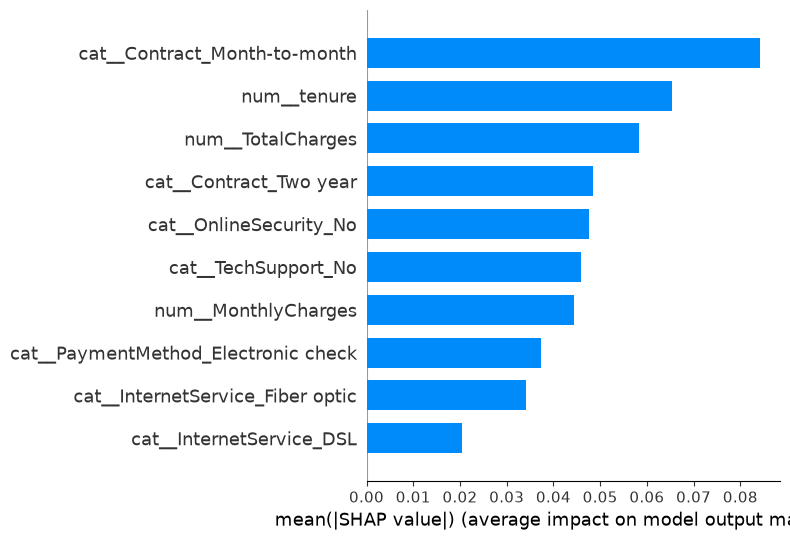

In [7]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# y_train(0/1) 비율이 샘플에서도 유지되도록 "층화(stratified) 샘플링"
n = 1000
n1 = int(round(n * y_train.mean()))  # 이탈(1) 개수
n0 = n - n1                          # 유지(0) 개수

idx1 = y_train[y_train == 1].sample(n=min(n1, (y_train == 1).sum()), random_state=42).index
idx0 = y_train[y_train == 0].sample(n=min(n0, (y_train == 0).sum()), random_state=42).index
shap_idx = idx0.union(idx1)

X_shap = X_train_prep.loc[shap_idx].sample(frac=1, random_state=42)  # 섞기

# TreeExplainer + 근사 SHAP (이탈=1 클래스)
explainer = shap.TreeExplainer(rf_all)
shap_values = explainer.shap_values(
    X_shap,
    approximate=True,
    check_additivity=False
)

if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
else:
    shap_values_churn = shap_values[:, :, 1]

# Summary Plot (bar) - 상위 10개
shap.summary_plot(
    shap_values_churn,
    X_shap,
    plot_type="bar",
    max_display=10
)

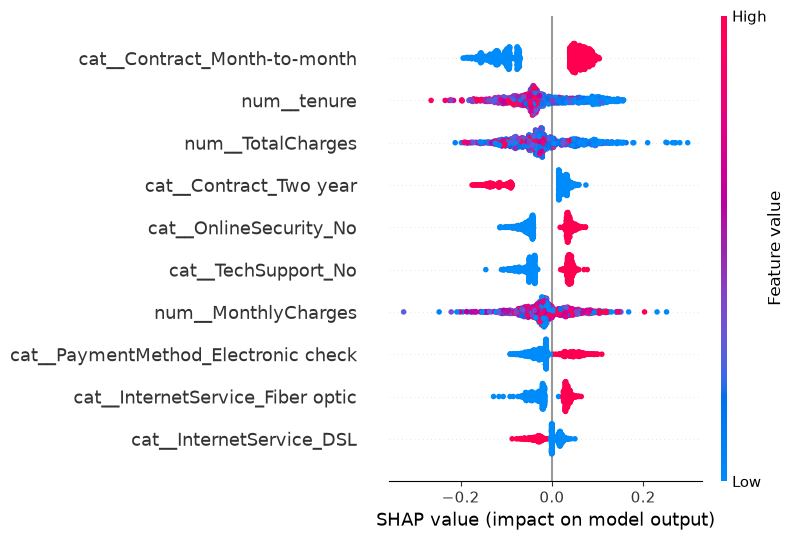

In [8]:
# 4) (선택) 점 형태 summary plot도 같이 보기 (방향까지 확인)
shap.summary_plot(
    shap_values_churn,
    X_shap,
    max_display=10
)

**[과제]** 써니는 실제로 이탈(Churn=1)로 예측된 고객 한 명을 골라서 Force Plot으로 어떤 변수들이 이탈 예측에 기여했는지 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

In [9]:
import shap
import numpy as np
import pandas as pd

# 0) (전제) rf_all, X_test_prep, y_test가 준비되어 있어야 함
# rf_all.predict_proba(X_test_prep)로 "이탈로 예측된" 고객을 고릅니다.

# 1) 이탈(1)로 예측된 고객 1명 선택 (확률이 가장 높은 고객)
proba = rf_all.predict_proba(X_test_prep)[:, 1]
pred = (proba >= 0.5).astype(int)

churn_pred_idx = X_test_prep.index[pred == 1]
print("이탈로 예측된 고객 수:", len(churn_pred_idx))

# 이탈 확률이 가장 높은 1명
top1_idx = churn_pred_idx[np.argmax(proba[pred == 1])]
print("선택된 고객 index:", top1_idx, "| predicted proba:", float(proba[X_test_prep.index.get_loc(top1_idx)]))

x_one = X_test_prep.loc[[top1_idx]]

# 2) SHAP 값 계산 (해당 1명만)
explainer = shap.TreeExplainer(rf_all)
shap_values = explainer.shap_values(x_one, check_additivity=False)

# 이탈(1) 클래스 SHAP 선택
if isinstance(shap_values, list):
    sv = shap_values[1][0]
    base = explainer.expected_value[1]
else:
    sv = shap_values[0, :, 1]
    base = explainer.expected_value[1]

# 3) Force plot (노트북에서 렌더링 활성화)
shap.initjs()
shap.force_plot(base, sv, x_one.iloc[0], matplotlib=False)

이탈로 예측된 고객 수: 660
선택된 고객 index: 3633 | predicted proba: 1.0


In [10]:
import shap
import numpy as np

# 0) (전제) rf_all, X_test_prep 가 준비되어 있어야 함

# 1) 이탈 확률 계산
proba = rf_all.predict_proba(X_test_prep)[:, 1]

# 2) 이탈 확률 내림차순 정렬해서 "100번째" 샘플 선택 (1부터 세면 100번째)
rank = 100
sorted_idx = np.argsort(-proba)              # 확률 큰 순서의 위치 index
pos = min(rank - 1, len(sorted_idx) - 1)     # 데이터가 100개 미만일 때 대비
row_pos = sorted_idx[pos]

case_idx = X_test_prep.index[row_pos]
print(f"선택 케이스: {rank}번째 (1-base) | index={case_idx} | proba={proba[row_pos]:.4f}")

x_one = X_test_prep.loc[[case_idx]]

# 3) SHAP (해당 1명만)
explainer = shap.TreeExplainer(rf_all)
shap_values = explainer.shap_values(x_one, check_additivity=False)

# 이탈(1) 클래스 SHAP 선택
if isinstance(shap_values, list):
    sv = shap_values[1][0]
    base = explainer.expected_value[1]
else:
    sv = shap_values[0, :, 1]
    base = explainer.expected_value[1]

# 4) Force plot
shap.initjs()
shap.force_plot(base, sv, x_one.iloc[0], matplotlib=False)

선택 케이스: 100번째 (1-base) | index=5599 | proba=0.8900


## 6) 분석 결과 종합 및 활용

**[과제]** 써니는 앞선 변수 선택 결과와 SHAP 분석을 종합해서, 이탈 고객을 막으려면 어떤 마케팅을 해야 할지 궁금합니다. AI와 상의하여 이탈로 예측된 고객들이 어떤 변수 때문에 그렇게 예측됐는지 파악하고 그에 맞는 마케팅 방식을 추천받아 보세요.

[AI의 대답]
지금 단계에서 할 수 있는 “선생님식” 결론은 이렇습니다.

- **mRMR/Boruta**는 “중요한 변수 후보가 무엇인지”를 좁혀주는 도구이고  
- **SHAP**은 “각 고객이 왜 이탈로 예측됐는지”를 고객 단위로 설명해줍니다.  
따라서 마케팅은 **SHAP으로 이탈 원인을 유형화(세그먼트화)** 한 뒤, 유형별 처방을 붙이는 방식이 가장 설득력 있습니다.

아래는 Telco churn에서 거의 항상 반복되는 **SHAP 기반 이탈 유형(원인) → 마케팅 처방** 템플릿입니다.  
(실제 상위 변수 10개와 force plot에서 “빨간(이탈↑)”으로 밀어 올린 변수들이 무엇인지에 따라 매칭해서 쓰면 됩니다.)

---

## 1) SHAP으로 “이탈 원인 유형”을 만드는 방법
이탈(1)로 예측된 고객에 대해,

- **이탈을 올리는(+) SHAP 기여 상위 3~5개 변수**를 뽑고
- 그 패턴이 비슷한 고객끼리 묶으면  
→ “이탈 원인 세그먼트”가 됩니다.

마케팅은 “모델이 지적한 원인”을 줄이거나, “장벽(락인)”을 만드는 방향이어야 합니다.

---

## 2) 대표 이탈 세그먼트별 마케팅 추천 (실무형)

### (A) **단기 가입(tenure 낮음)** + **Month-to-month 계약**
- **SHAP에서 보이는 신호**
  - `tenure`가 낮은 값일 때 이탈 방향(+) 기여
  - `Contract=Month-to-month`가 이탈 방향(+) 기여
- **해석**
  - “초기 경험/가격/설치 품질/기대 불일치”로 떠나는 유형
- **추천 마케팅**
  - **초기 30~90일 온보딩/리텐션 캠페인** (문제 해결 중심)
  - **1년 약정 전환 인센티브**: 1~2개월 할인, 기기/설치비 면제, 업그레이드 쿠폰
  - “가입 2~3개월차”에 **불만 징후(고객센터/품질)** 있으면 우선 케어

### (B) **Electronic check 결제** + **PaperlessBilling**
- **SHAP 신호**
  - `PaymentMethod=Electronic check`가 이탈(+)로 자주 뜸
- **해석**
  - 연체/불편/자동이체 미등록 고객군이 섞이는 경우가 많음
- **추천 마케팅**
  - **자동이체(카드/계좌이체) 전환 혜택**: 전환 시 1개월 할인, 포인트 적립
  - 결제 실패 사전 알림 + 납부 편의 UX 개선 메시지
  - “전자수표+월단위” 조합이면 우선 타겟

### (C) **Fiber optic** + **높은 MonthlyCharges**
- **SHAP 신호**
  - `InternetService=Fiber optic`와 `MonthlyCharges` 높은 값이 이탈(+) 기여
- **해석**
  - 고요금 대비 체감가치 부족(품질/혜택/경쟁사 가격)
- **추천 마케팅**
  - **요금제 리밸런싱 제안**: 번들/약정/장기고객 할인
  - **품질 보장/속도 점검 캠페인**: 불만 사전 차단(특히 “Fiber+고요금+단기”는 강한 위험)
  - OTT/보안/백업 등 **부가서비스 묶음 가치 제시** (가격이 아닌 가치로 방어)

### (D) **OnlineSecurity/TechSupport = No** (보안·기술지원 미가입)
- **SHAP 신호**
  - `OnlineSecurity=No`, `TechSupport=No`가 이탈(+)로 기여하는 경우가 흔함
- **해석**
  - 단순 가격 민감층이거나, 장애 경험 시 떠날 가능성이 큼
- **추천 마케팅**
  - **보안/기술지원 체험(무료 1~3개월)** 후 유지 시 할인
  - 장애/불편 이력이 있는 고객에게 **우선 지원 채널 제공**

### (E) **StreamingTV/Movies = Yes** 등 엔터 이용자
- **SHAP 신호**
  - 스트리밍 관련 옵션이 조합으로 이탈(+)에 기여하는 경우가 있음(가격 부담/번들 부재)
- **추천 마케팅**
  - **스트리밍 번들 할인** 또는 “요금제 내 포함” 업셀/크로셀
  - 경쟁 OTT 대비 혜택 메시지

---

## 3) “어떤 고객에게 어떤 캠페인을 보낼지” 실행 규칙(간단)
- 이탈 예측 고객 중에서,
  - **SHAP 상위 기여가 `Contract=Month-to-month`** → 약정 전환 오퍼
  - **SHAP 상위 기여가 `MonthlyCharges` 높음** → 요금 최적화/번들 제안
  - **SHAP 상위 기여가 `Electronic check`** → 자동이체 전환 혜택
  - **SHAP 상위 기여가 `TechSupport=No`** → 기술지원/품질 케어 오퍼  
처럼 “원인 1순위”로 오퍼를 매칭하면 됩니다.

---

## 4) 중요한 주의점 (선생님처럼 꼭 짚는 부분)
- SHAP은 “이 모델이 이렇게 판단했다”는 설명이지, **인과관계(원인)** 를 보장하진 않습니다.  
  그래서 캠페인은 반드시 **A/B 테스트**로 효과를 검증해야 합니다.
- Precision이 0.56대였죠. 즉, “이탈이라고 찍힌 사람” 중 일부는 실제로 안 떠납니다.  
  → 할인 남발을 막으려면, **이탈 확률 상위 구간(예: 상위 10~20%)** 또는 **SHAP 기여가 큰 고객**에 우선 적용하는 게 좋습니다.

---

## 5) 당신의 노트북 결과에 맞춰 “정확히” 추천하려면 필요한 것
지금 제가 일반적인 템플릿을 드렸고, **여러분의 SHAP summary bar 상위 10개 변수명**과 “이탈로 예측된 고객들”의 **force plot 상위 기여 변수**가 나오면, 그 결과에 맞춰

- “이번 데이터에서는 특히 **무엇이 1순위 이탈 요인**이고”
- “그 요인별로 어떤 캠페인이 최우선인지”
를 더 구체적으로 정리해 드릴 수 있어요.

가능하면 SHAP summary bar plot의 **상위 10개 변수 리스트(그림 또는 출력)** 와, 이탈 예측 고객 2~3명의 **force plot에서 +로 크게 기여한 변수 3개씩**만 알려주세요. 그러면 “이 수업 데이터 기준”으로 맞춤 마케팅 제안을 딱 만들어드릴게요.